In [23]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-07.parquet')

In [24]:
df.shape

(3898963, 20)

In [25]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3120417,2,2025-07-10 07:30:14,2025-07-10 07:51:33,NaN,3.25,NaN,None,142,137,0,29.71,0.0,0.5,5.17,0.0,1.0,39.63,NaN,NaN,0.75
71083,2,2025-07-01 18:37:43,2025-07-01 18:56:45,2.0,3.63,1.0,N,41,167,2,19.80,2.5,0.5,0.00,0.0,1.0,23.80,0.0,0.0,0.00
1396082,2,2025-07-16 19:46:21,2025-07-16 19:50:08,1.0,0.76,1.0,N,170,229,1,6.50,2.5,0.5,1.00,0.0,1.0,14.75,2.5,0.0,0.75


In [26]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1038755
trip_distance                  0
RatecodeID               1038755
store_and_fwd_flag       1038755
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1038755
Airport_fee              1038755
cbd_congestion_fee             0
dtype: int64

In [27]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [28]:
df[df.duplicated()].shape

(1, 20)

In [29]:
df = df.drop_duplicates()

In [30]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-07-01') | (df["tpep_pickup_datetime"] >= '2025-08-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
33,2,2025-06-30 23:56:19,2025-07-01 00:01:50,3.0,0.70,1.0,N,161,233,1,7.20,1.0,0.5,3.88,0.0,1.0,16.83,2.5,0.0,0.75
229,2,2025-06-30 23:59:59,2025-07-01 00:07:12,3.0,1.37,1.0,N,238,236,1,9.30,1.0,0.5,1.00,0.0,1.0,15.30,2.5,0.0,0.00
232,2,2025-06-30 23:57:41,2025-07-01 00:19:08,1.0,6.44,1.0,N,114,42,1,27.50,1.0,0.5,8.31,0.0,1.0,41.56,2.5,0.0,0.75
607,7,2025-07-01 00:02:38,2025-07-01 00:02:38,1.0,3.75,1.0,N,141,144,1,16.30,0.0,0.5,5.51,0.0,1.0,27.56,2.5,0.0,0.75
609,2,2025-06-30 23:55:06,2025-07-01 00:14:27,1.0,4.35,1.0,N,234,142,1,23.30,1.0,0.5,5.81,0.0,1.0,34.86,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3747133,2,2025-07-27 17:02:00,2025-07-27 17:02:00,NaN,0.01,NaN,None,147,147,0,4.64,0.0,0.5,0.00,0.0,1.0,6.14,NaN,NaN,0.00
3810727,2,2025-07-29 19:10:33,2025-07-29 19:10:33,NaN,0.97,NaN,None,164,164,0,18.37,0.0,0.5,0.00,0.0,1.0,23.12,NaN,NaN,0.75
3825496,2,2025-07-30 07:33:00,2025-07-30 07:33:00,NaN,0.02,NaN,None,65,65,0,20.83,0.0,0.5,0.00,0.0,1.0,22.33,NaN,NaN,0.00
3827384,2,2025-07-30 08:10:00,2025-07-30 08:10:00,NaN,0.05,NaN,None,170,170,0,14.98,0.0,0.5,0.00,0.0,1.0,19.73,NaN,NaN,0.75


In [31]:
# проблемных строк 54562
# 54562 записей составляют ~1.4% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [32]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [33]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
822,2,2025-07-01 00:30:49,2025-07-01 00:50:14,3.0,4.88,1.0,N,264,264,1,22.60,1.0,0.5,8.50,0.0,1.0,36.85,2.5,0.0,0.75
1010,2,2025-07-01 00:18:56,2025-07-01 00:25:36,1.0,1.02,1.0,N,264,264,1,8.60,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
1011,2,2025-07-01 00:26:39,2025-07-01 00:34:25,1.0,1.15,1.0,N,264,264,1,9.30,1.0,0.5,0.00,0.0,1.0,15.05,2.5,0.0,0.75
1012,2,2025-07-01 00:43:46,2025-07-01 00:50:11,1.0,1.01,1.0,N,264,264,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.0,0.00
1730,2,2025-07-01 01:46:48,2025-07-01 01:56:15,1.0,3.46,1.0,N,264,92,2,16.30,1.0,0.5,0.00,0.0,1.0,18.80,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3875086,2,2025-07-31 14:28:08,2025-07-31 15:08:46,NaN,7.37,NaN,None,264,264,0,42.87,0.0,0.5,0.00,0.0,1.0,46.87,NaN,NaN,0.00
3885948,1,2025-07-31 18:27:21,2025-07-31 18:49:19,NaN,1.90,NaN,None,264,164,0,19.10,2.5,0.5,3.95,0.0,1.0,30.30,NaN,NaN,0.75
3887939,2,2025-07-31 19:12:36,2025-07-31 19:13:04,NaN,0.00,NaN,None,264,264,0,35.59,0.0,0.5,0.00,0.0,1.0,39.59,NaN,NaN,0.00
3888402,2,2025-07-31 19:12:44,2025-07-31 19:40:37,NaN,6.60,NaN,None,264,264,0,32.78,0.0,0.5,0.00,0.0,1.0,34.28,NaN,NaN,0.00


In [34]:
# записей с зоной 264 всего 6114
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [35]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 3898963-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 60677
осталось записей о поездке: 3838286
максимальная и минимальная даты в таблице: 2025-07-31 23:59:59 2025-07-01 00:00:00


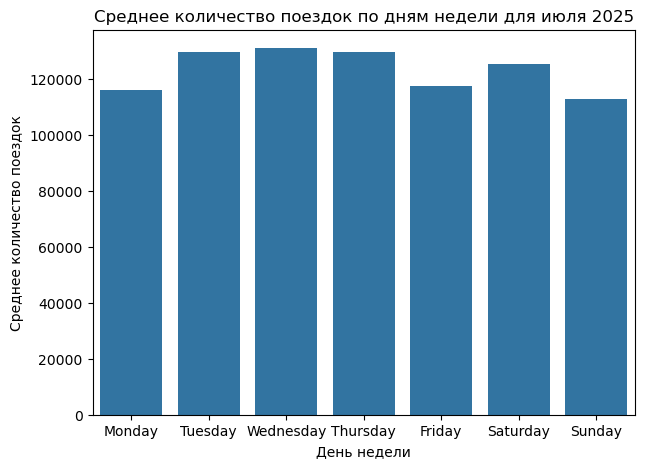

In [36]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для июля 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

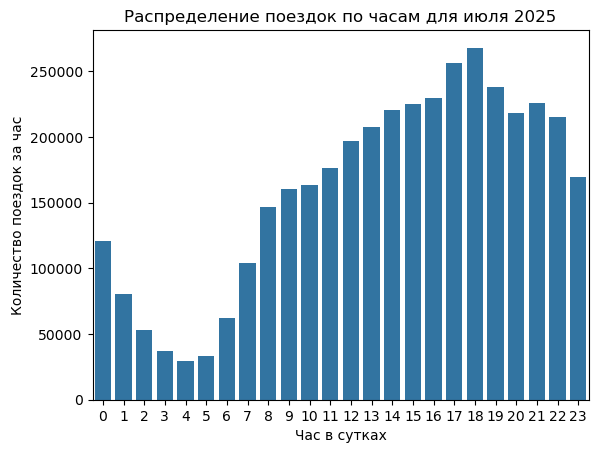

In [37]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для июля 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

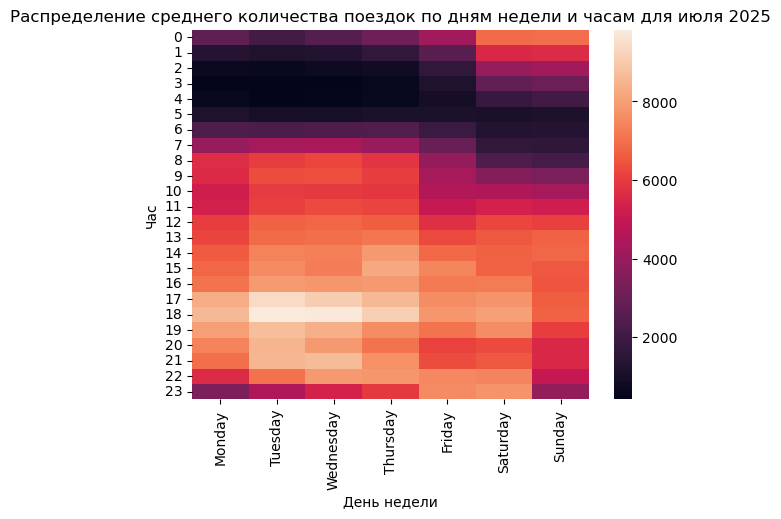

In [38]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для июля 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [39]:
# Графики распределений не имеют значимых отличий от июньских, пик активности - вторник в 18 ч,
# прошлый пик активности в среду в 18 ч отличается совсем немного,
# а вот количество заказов в четверг в 18 ч (пик активности в мае) упало значимо.

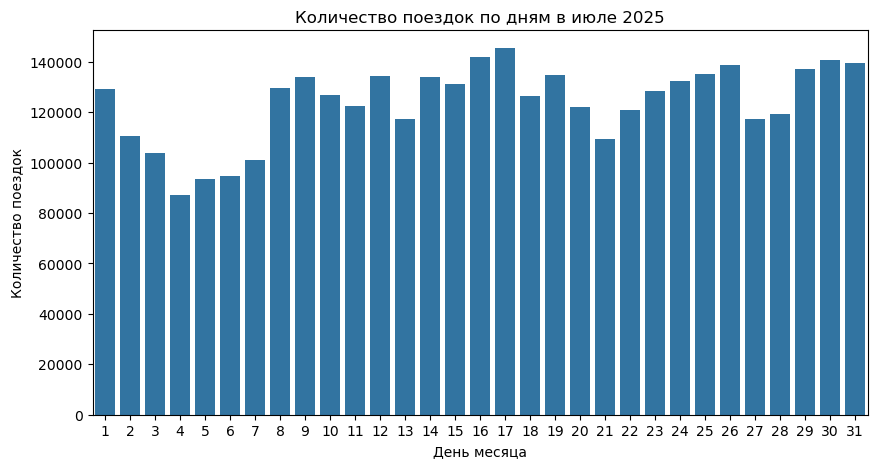

In [40]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в июле 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн прошлых месяцев сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 7, 14, 21, 28 июля.
# Интересно, что 4 июля (День независимости в США) в семейный праздник наблюдается 
# самое малое количество поездок за весь месяц. Также тенденция сохраняется в выходные дни 5 и 6 июля.

In [41]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,353
EWR,496
Bronx,34486
Brooklyn,167759
Queens,412420
Manhattan,3220527


In [46]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-07-01,0,79,62
1,2025-07-01,0,161,86
2,2025-07-01,0,163,38
3,2025-07-01,0,186,55
4,2025-07-01,0,239,21
...,...,...,...,...
3715,2025-07-31,23,79,257
3716,2025-07-31,23,161,213
3717,2025-07-31,23,163,121
3718,2025-07-31,23,186,157


In [43]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей, так и есть.

In [44]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_07.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [45]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
